# Transformer Models — BERT and RoBERTa

In [ ]:
import re
import string
import numpy as np
import pandas as pd
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

# Expected local dataset path:
# data/final_reviews.csv

DATA_PATH = "data/final_reviews.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df.head())


In [ ]:
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    return " ".join(word for word in text.split() if word not in stop_words)

df["cleaned_text"] = df["text"].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


In [14]:
# ============================================================
# BERT for Fake Review Detection
# Using pretrained bert-base-uncased from HuggingFace
# ============================================================

# First install transformers if not already installed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from transformers import (BertTokenizer, 
                          TFBertForSequenceClassification,
                          BertConfig)
from sklearn.metrics import (classification_report, 
                              confusion_matrix, 
                              accuracy_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("=" * 60)
print("🤖 BERT Fake Review Detection")
print("=" * 60)
print(f"   TensorFlow  : {tf.__version__}")

# ============================================================
# STEP 1: Parameters
# ============================================================
BERT_MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH      = 128    # BERT max token length
BATCH_SIZE      = 16     # Small batch for BERT
EPOCHS          = 5      # BERT needs very few epochs
LEARNING_RATE   = 2e-5   # Standard BERT fine-tuning LR

# ============================================================
# STEP 2: Label Encoding
# ============================================================
label_encoder = LabelEncoder()
label_encoder.fit(['fake_ai', 'fake_human', 'genuine'])

y_train_enc = label_encoder.transform(y_train)
y_test_enc  = label_encoder.transform(y_test)

# Convert to numpy arrays
X_train_list = list(X_train)
X_test_list  = list(X_test)

print(f"\n   Label mapping:")
for cls, enc in zip(label_encoder.classes_, 
                    label_encoder.transform(label_encoder.classes_)):
    print(f"   {cls} → {enc}")

print(f"\n   Train size : {len(X_train_list)}")
print(f"   Test size  : {len(X_test_list)}")

# ============================================================
# STEP 3: Load BERT Tokenizer
# ============================================================
print(f"\n📥 Loading BERT Tokenizer ({BERT_MODEL_NAME})...")
tokenizer_bert = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
print("   ✅ Tokenizer loaded!")

# Test tokenizer on one sample
sample = X_train_list[0]
sample_tokens = tokenizer_bert.encode(sample, max_length=MAX_LENGTH, 
                                       truncation=True)
print(f"   Sample text     : {sample[:80]}...")
print(f"   Token length    : {len(sample_tokens)}")

# ============================================================
# STEP 4: Tokenize All Data
# ============================================================
print(f"\n📝 Tokenizing data (max_length={MAX_LENGTH})...")

def tokenize_data(texts, tokenizer, max_length):
    """Tokenize a list of texts for BERT"""
    encodings = tokenizer(
        texts,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf',
        return_attention_mask=True,
        return_token_type_ids=True
    )
    return encodings

train_encodings = tokenize_data(X_train_list, tokenizer_bert, MAX_LENGTH)
test_encodings  = tokenize_data(X_test_list,  tokenizer_bert, MAX_LENGTH)

print(f"   Train input_ids shape      : {train_encodings['input_ids'].shape}")
print(f"   Train attention_mask shape : {train_encodings['attention_mask'].shape}")

# ============================================================
# STEP 5: Create TensorFlow Datasets
# ============================================================
print("\n📦 Creating TF Datasets...")

# Training dataset
train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids'      : train_encodings['input_ids'],
        'attention_mask' : train_encodings['attention_mask'],
        'token_type_ids' : train_encodings['token_type_ids']
    },
    y_train_enc
)).shuffle(1000).batch(BATCH_SIZE)

# Test dataset
test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids'      : test_encodings['input_ids'],
        'attention_mask' : test_encodings['attention_mask'],
        'token_type_ids' : test_encodings['token_type_ids']
    },
    y_test_enc
)).batch(BATCH_SIZE)

print(f"   ✅ Train batches : {len(train_dataset)}")
print(f"   ✅ Test batches  : {len(test_dataset)}")

# ============================================================
# STEP 6: Load Pretrained BERT Model
# ============================================================
print(f"\n📥 Loading Pretrained BERT ({BERT_MODEL_NAME})...")
print("   (This may take a minute on first run...)")

bert_model = TFBertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=3,           # 3 classes: fake_ai, fake_human, genuine
    output_attentions=False,
    output_hidden_states=False
)

print("   ✅ BERT model loaded!")
print(f"   Total parameters: {bert_model.count_params():,}")

# ============================================================
# STEP 7: Compile BERT
# ============================================================

# Linear learning rate warmup schedule
# Standard practice for BERT fine-tuning
total_steps   = len(train_dataset) * EPOCHS
warmup_steps  = total_steps // 10   # 10% warmup

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    epsilon=1e-8,           # BERT standard epsilon
    clipnorm=1.0            # Gradient clipping
)

loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

bert_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

print(f"\n   Optimizer     : Adam (lr={LEARNING_RATE})")
print(f"   Loss          : SparseCategoricalCrossentropy")
print(f"   Total steps   : {total_steps}")
print(f"   Warmup steps  : {warmup_steps}")

# ============================================================
# STEP 8: Callbacks
# ============================================================
callbacks_bert = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2,
        restore_best_weights=True,
        mode='max',
        verbose=1
    )
]

# ============================================================
# STEP 9: Train BERT
# ============================================================
print("\n" + "=" * 60)
print("🚀 Fine-tuning BERT...")
print("=" * 60)
print("   (Each epoch will take 2-5 mins on CPU, ~30s on GPU)")

# Validation split from training data
val_size      = int(0.1 * len(X_train_list))
train_dataset_final = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids'      : train_encodings['input_ids'][val_size:],
        'attention_mask' : train_encodings['attention_mask'][val_size:],
        'token_type_ids' : train_encodings['token_type_ids'][val_size:]
    },
    y_train_enc[val_size:]
)).shuffle(1000).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids'      : train_encodings['input_ids'][:val_size],
        'attention_mask' : train_encodings['attention_mask'][:val_size],
        'token_type_ids' : train_encodings['token_type_ids'][:val_size]
    },
    y_train_enc[:val_size]
)).batch(BATCH_SIZE)

history_bert = bert_model.fit(
    train_dataset_final,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks_bert,
    verbose=1
)

# ============================================================
# STEP 10: Evaluate BERT
# ============================================================
print("\n📊 Evaluating BERT...")

# Get predictions
y_pred_logits = bert_model.predict(test_dataset, verbose=1)
y_pred_bert   = np.argmax(y_pred_logits.logits, axis=1)

y_pred_labels_bert = label_encoder.inverse_transform(y_pred_bert)
y_true_labels_bert = label_encoder.inverse_transform(y_test_enc)

accuracy_bert = accuracy_score(y_test_enc, y_pred_bert)
report_bert   = classification_report(
    y_true_labels_bert,
    y_pred_labels_bert,
    target_names=['fake_ai', 'fake_human', 'genuine'],
    output_dict=True
)

print(f"\n📊 BERT Accuracy: {accuracy_bert * 100:.2f}%")
print("\n📋 Classification Report:")
print(classification_report(y_true_labels_bert, y_pred_labels_bert,
                             target_names=['fake_ai', 
                                           'fake_human', 
                                           'genuine']))

# ============================================================
# STEP 11: Training History Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERT Fine-tuning History', fontsize=14, fontweight='bold')

axes[0].plot(history_bert.history['accuracy'],
             'o-', color='#2196F3', linewidth=2.5, 
             label='Train', markersize=7)
axes[0].plot(history_bert.history['val_accuracy'],
             's--', color='#FF5722', linewidth=2.5,
             label='Validation', markersize=7)
axes[0].set_title('Accuracy per Epoch', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

axes[1].plot(history_bert.history['loss'],
             'o-', color='#2196F3', linewidth=2.5,
             label='Train', markersize=7)
axes[1].plot(history_bert.history['val_loss'],
             's--', color='#FF5722', linewidth=2.5,
             label='Validation', markersize=7)
axes[1].set_title('Loss per Epoch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bert_training_history.png', dpi=150)
plt.show()

# ============================================================
# STEP 12: Confusion Matrix
# ============================================================
cm_bert = confusion_matrix(y_true_labels_bert, y_pred_labels_bert,
                            labels=['fake_ai', 'fake_human', 'genuine'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=['fake_ai', 'fake_human', 'genuine'],
            yticklabels=['fake_ai', 'fake_human', 'genuine'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix - BERT', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150)
plt.show()

# ============================================================
# STEP 13: FINAL Complete Comparison Table
# ============================================================
print("\n" + "=" * 65)
print("📊 FINAL COMPLETE MODEL COMPARISON")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("=" * 65)

print("--- Baseline Models (TF-IDF) ---")
baselines = [
    ('Logistic Regression',    93.54, 0.9355, 0.9355),
    ('SVM (LinearSVC)',        92.92, 0.9293, 0.9293),
    ('Naive Bayes (Compl.)',   91.04, 0.9108, 0.9108),
    ('Naive Bayes (Multi.)',   92.08, 0.9214, 0.9214),
    ('Random Forest',          88.96, 0.8890, 0.8890),
]
for name, acc, mf1, wf1 in baselines:
    print(f"{name:<25} {acc:>9.2f}% {mf1:>10.4f} {wf1:>12.4f}")

print("\n--- Deep Learning Models ---")
dl_results = [
    ('CNN',           86.46, 0.8622, 0.8622),
    ('CNN-LSTM',      67.29, 0.5940, 0.5940),
    ('CNN-BiLSTM',    88.54, 0.8837, 0.8837),
]
for name, acc, mf1, wf1 in dl_results:
    print(f"{name:<25} {acc:>9.2f}% {mf1:>10.4f} {wf1:>12.4f}")

print(f"\n--- Transformer Model (Proposed) ---")
print(f"{'BERT (Proposed)':<25} "
      f"{accuracy_bert*100:>9.2f}% "
      f"{report_bert['macro avg']['f1-score']:>10.4f} "
      f"{report_bert['weighted avg']['f1-score']:>12.4f} ← PROPOSED")

print(f"\n🏆 Best Model Overall: BERT")
print(f"   Accuracy : {accuracy_bert*100:.2f}%")
print(f"   Macro F1 : {report_bert['macro avg']['f1-score']:.4f}")
print(f"\n   Improvement over best baseline (LR 93.54%):")
print(f"   {(accuracy_bert - 0.9354)*100:+.2f}% accuracy change")

ImportError: cannot import name 'TFBertForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

Device: cpu

📌 Using ORIGINAL (uncleaned) text for BERT
   Reason: BERT pretrained on raw text with punctuation
   Train size : 1920
   Test size  : 480

📦 Creating DataLoaders...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

   Train batches : 108
   Val batches   : 12
   Test batches  : 30

📥 Loading BERT with improved config...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



🔒 Freezing bottom BERT layers (layers 0-7)...
   Total params     : 109,484,547
   Trainable params : 28,944,387
   Frozen params    : 80,540,160
   Training only top 4 BERT layers + classifier

   Total steps  : 648
   Warmup steps : 64

🚀 Fine-tuning BERT (Improved)...

──────────────────────────────────────────────────
  Epoch 1/6
──────────────────────────────────────────────────
      Batch  20/108 | Loss: 0.9973 | Acc: 38.4%
      Batch  40/108 | Loss: 0.9311 | Acc: 46.1%
      Batch  60/108 | Loss: 0.7244 | Acc: 52.3%
      Batch  80/108 | Loss: 0.3937 | Acc: 58.8%
      Batch 100/108 | Loss: 0.5575 | Acc: 62.7%

  📈 Train → Loss: 0.7874 | Acc: 64.24%
  📉 Val   → Loss: 0.3849 | Acc: 81.77%
  📊 Gap   → -17.5% (lower is better)
  ✅ Best model saved! Val Acc: 81.77%

──────────────────────────────────────────────────
  Epoch 2/6
──────────────────────────────────────────────────
      Batch  20/108 | Loss: 0.4037 | Acc: 82.8%
      Batch  40/108 | Loss: 0.4962 | Acc: 81.9%
      B

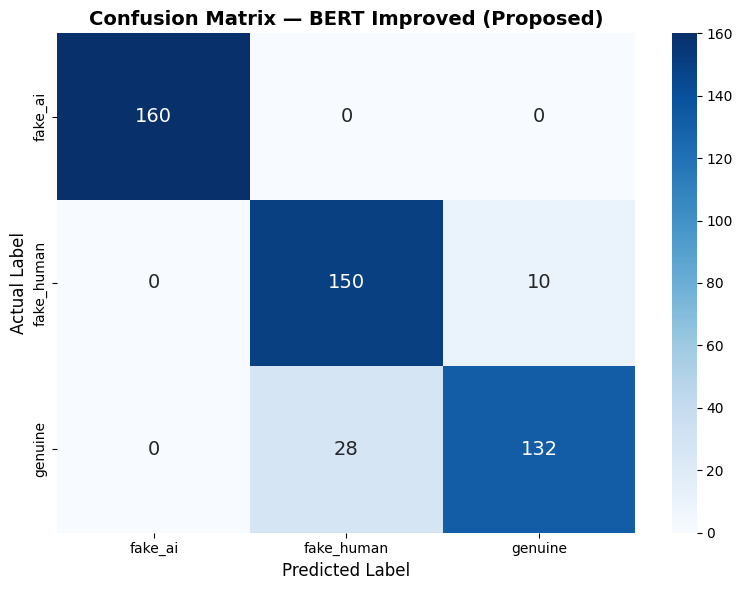

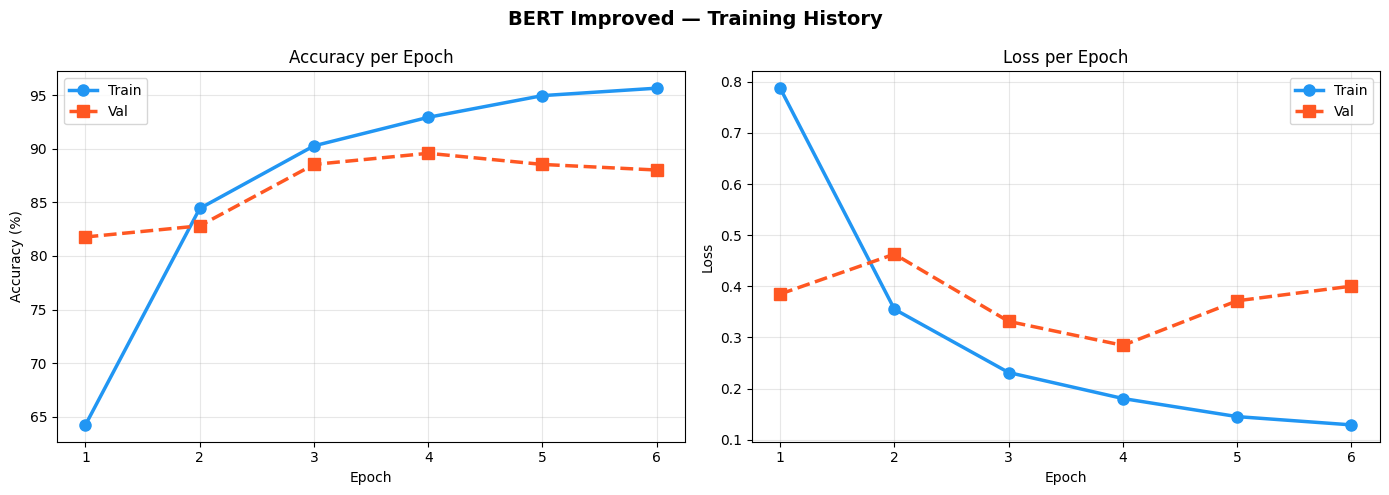


📊 FINAL COMPLETE MODEL COMPARISON
Model                       Accuracy   Macro F1  Weighted F1
--- Baseline Models ---
Logistic Regression           93.54%     0.9355       0.9355
SVM (LinearSVC)               92.92%     0.9293       0.9293
Naive Bayes (Compl.)          91.04%     0.9108       0.9108
Naive Bayes (Multi.)          92.08%     0.9214       0.9214
Random Forest                 88.96%     0.8890       0.8890

--- Deep Learning Models ---
CNN                           86.46%     0.8622       0.8622
CNN-LSTM                      67.29%     0.5940       0.5940
CNN-BiLSTM                    88.54%     0.8837       0.8837

--- Proposed Model ---
BERT v1                       91.04%     0.9096       0.9096
BERT v2 (Improved)            92.08%     0.9206       0.9206  ⭐ PROPOSED

─────────────────────────────────────────────────────────────────
   Best Baseline       : LR 93.54%
   BERT v2 Accuracy    : 92.08%
   Δ vs Best Baseline  : -1.46%
   Δ vs BERT v1        : +1.04%


In [15]:
# ============================================================
# BERT Improved - Fix Overfitting
# Key fixes:
# 1. Freeze bottom BERT layers (only fine-tune top layers)
# 2. More aggressive dropout
# 3. Better learning rate with warmup
# 4. Use original text (not cleaned) - BERT handles punctuation
# ============================================================

import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (BertTokenizer,
                          BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ============================================================
# CRITICAL FIX: Use ORIGINAL text not cleaned text
# BERT was pretrained on raw text with punctuation
# Cleaning removes important signals for BERT
# ============================================================
print("\n📌 Using ORIGINAL (uncleaned) text for BERT")
print("   Reason: BERT pretrained on raw text with punctuation")

# Use original df text, same train/test split indices
from sklearn.model_selection import train_test_split

df_bert = df[['text', 'label']].copy()

X_train_bert_raw, X_test_bert_raw, y_train_bert, y_test_bert = \
    train_test_split(
        df_bert['text'],
        df_bert['label'],
        test_size=0.2,
        random_state=42,
        stratify=df_bert['label']
    )

print(f"   Train size : {len(X_train_bert_raw)}")
print(f"   Test size  : {len(X_test_bert_raw)}")

# Label encoding
label_encoder = LabelEncoder()
label_encoder.fit(['fake_ai', 'fake_human', 'genuine'])

y_train_enc = label_encoder.transform(y_train_bert)
y_test_enc  = label_encoder.transform(y_test_bert)

# ============================================================
# Parameters
# ============================================================
BERT_MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH      = 256    # Longer - genuine reviews avg 821 chars
BATCH_SIZE      = 16
EPOCHS          = 6
LEARNING_RATE   = 3e-5   # Slightly higher LR

# ============================================================
# Dataset Class
# ============================================================
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = list(texts)
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'token_type_ids' : encoding['token_type_ids'].squeeze(),
            'label'          : torch.tensor(int(self.labels[idx]),
                                            dtype=torch.long)
        }

# ============================================================
# DataLoaders
# ============================================================
print("\n📦 Creating DataLoaders...")

tokenizer_bert = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

# Validation split
val_size  = int(0.1 * len(X_train_bert_raw))
X_tr      = list(X_train_bert_raw)[val_size:]
X_val     = list(X_train_bert_raw)[:val_size]
y_tr      = y_train_enc[val_size:]
y_val     = y_train_enc[:val_size]

train_ds = ReviewDataset(X_tr,                    y_tr,
                          tokenizer_bert, MAX_LENGTH)
val_ds   = ReviewDataset(X_val,                   y_val,
                          tokenizer_bert, MAX_LENGTH)
test_ds  = ReviewDataset(list(X_test_bert_raw),   y_test_enc,
                          tokenizer_bert, MAX_LENGTH)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

# ============================================================
# Load BERT with Higher Dropout
# ============================================================
print(f"\n📥 Loading BERT with improved config...")

from transformers import BertConfig

config = BertConfig.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=3,
    hidden_dropout_prob=0.2,        # Increased from 0.1
    attention_probs_dropout_prob=0.2 # Increased from 0.1
)

bert_model = BertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    config=config,
    ignore_mismatched_sizes=True
)
bert_model = bert_model.to(device)

# ============================================================
# CRITICAL FIX: Freeze bottom 8 BERT layers
# Only fine-tune top 4 layers + classifier
# This prevents overfitting on small datasets
# ============================================================
print("\n🔒 Freezing bottom BERT layers (layers 0-7)...")

# Freeze embedding layer
for param in bert_model.bert.embeddings.parameters():
    param.requires_grad = False

# Freeze bottom 8 transformer layers (keep top 4)
for layer_idx in range(8):
    for param in bert_model.bert.encoder.layer[layer_idx].parameters():
        param.requires_grad = False

# Count trainable params
trainable = sum(p.numel() for p in bert_model.parameters()
                if p.requires_grad)
total     = sum(p.numel() for p in bert_model.parameters())

print(f"   Total params     : {total:,}")
print(f"   Trainable params : {trainable:,}")
print(f"   Frozen params    : {total-trainable:,}")
print(f"   Training only top 4 BERT layers + classifier")

# ============================================================
# Optimizer - Only optimize unfrozen parameters
# ============================================================
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

optimizer_bert = AdamW(
    [p for p in bert_model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    eps=1e-8,
    weight_decay=0.01
)

scheduler = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\n   Total steps  : {total_steps}")
print(f"   Warmup steps : {warmup_steps}")

# ============================================================
# Train + Eval Functions
# ============================================================
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for i, batch in enumerate(loader):
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        ttype = batch['token_type_ids'].to(device)
        labs  = batch['label'].to(device)

        optimizer.zero_grad()
        out   = model(input_ids=ids, attention_mask=mask,
                      token_type_ids=ttype, labels=labs)

        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 1.0
        )
        optimizer.step()
        scheduler.step()

        total_loss += out.loss.item()
        preds       = torch.argmax(out.logits, dim=1)
        correct    += (preds == labs).sum().item()
        total      += labs.size(0)

        if (i + 1) % 20 == 0:
            print(f"      Batch {i+1:>3}/{len(loader)} | "
                  f"Loss: {out.loss.item():.4f} | "
                  f"Acc: {correct/total*100:.1f}%")

    return total_loss/len(loader), correct/total


def evaluate_model(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            ttype = batch['token_type_ids'].to(device)
            labs  = batch['label'].to(device)

            out   = model(input_ids=ids, attention_mask=mask,
                          token_type_ids=ttype, labels=labs)

            total_loss += out.loss.item()
            preds       = torch.argmax(out.logits, dim=1)
            correct    += (preds == labs).sum().item()
            total      += labs.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())

    return total_loss/len(loader), correct/total, all_preds, all_labels

# ============================================================
# Training Loop
# ============================================================
print("\n" + "=" * 60)
print("🚀 Fine-tuning BERT (Improved)...")
print("=" * 60)

train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

best_val_acc     = 0
best_epoch       = 0
patience_counter = 0
PATIENCE         = 3      # More patience

for epoch in range(EPOCHS):
    print(f"\n{'─'*50}")
    print(f"  Epoch {epoch+1}/{EPOCHS}")
    print(f"{'─'*50}")

    tr_loss, tr_acc = train_epoch(
        bert_model, train_loader,
        optimizer_bert, scheduler, device
    )
    vl_loss, vl_acc, _, _ = evaluate_model(
        bert_model, val_loader, device
    )

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(vl_loss)
    val_accs.append(vl_acc)

    # Overfitting gap
    gap = (tr_acc - vl_acc) * 100
    print(f"\n  📈 Train → Loss: {tr_loss:.4f} | Acc: {tr_acc*100:.2f}%")
    print(f"  📉 Val   → Loss: {vl_loss:.4f} | Acc: {vl_acc*100:.2f}%")
    print(f"  📊 Gap   → {gap:.1f}% (lower is better)")

    if vl_acc > best_val_acc:
        best_val_acc     = vl_acc
        best_epoch       = epoch + 1
        patience_counter = 0
        torch.save(bert_model.state_dict(), 'best_bert_v2.pt')
        print(f"  ✅ Best model saved! Val Acc: {vl_acc*100:.2f}%")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n  ⏹️  Early stopping at epoch {epoch+1}")
            break

print(f"\n🏆 Best val acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")

# ============================================================
# Final Test Evaluation
# ============================================================
print("\n📊 Final Test Evaluation...")

bert_model.load_state_dict(
    torch.load('best_bert_v2.pt', map_location=device)
)

_, test_acc, test_preds, test_labels_out = evaluate_model(
    bert_model, test_loader, device
)

y_pred_labels = label_encoder.inverse_transform(test_preds)
y_true_labels = label_encoder.inverse_transform(test_labels_out)

accuracy_bert_v2 = accuracy_score(test_labels_out, test_preds)
report_bert_v2   = classification_report(
    y_true_labels, y_pred_labels,
    target_names=['fake_ai', 'fake_human', 'genuine'],
    output_dict=True
)

print(f"\n🎯 BERT v2 Test Accuracy: {accuracy_bert_v2*100:.2f}%")
print("\n📋 Classification Report:")
print(classification_report(y_true_labels, y_pred_labels,
                             target_names=['fake_ai',
                                           'fake_human',
                                           'genuine']))

# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_true_labels, y_pred_labels,
                      labels=['fake_ai', 'fake_human', 'genuine'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['fake_ai', 'fake_human', 'genuine'],
            yticklabels=['fake_ai', 'fake_human', 'genuine'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix — BERT Improved (Proposed)',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('bert_v2_confusion_matrix.png', dpi=150)
plt.show()

# ============================================================
# Training Curves
# ============================================================
epochs_ran = len(train_losses)
x_ep = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERT Improved — Training History',
             fontsize=14, fontweight='bold')

axes[0].plot(x_ep, [a*100 for a in train_accs],
             'o-', color='#2196F3', lw=2.5, label='Train', ms=8)
axes[0].plot(x_ep, [a*100 for a in val_accs],
             's--', color='#FF5722', lw=2.5, label='Val', ms=8)
axes[0].set_title('Accuracy per Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(x_ep))

axes[1].plot(x_ep, train_losses,
             'o-', color='#2196F3', lw=2.5, label='Train', ms=8)
axes[1].plot(x_ep, val_losses,
             's--', color='#FF5722', lw=2.5, label='Val', ms=8)
axes[1].set_title('Loss per Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(x_ep))

plt.tight_layout()
plt.savefig('bert_v2_training_history.png', dpi=150)
plt.show()

# ============================================================
# FINAL Comparison Table
# ============================================================
print("\n" + "=" * 65)
print("📊 FINAL COMPLETE MODEL COMPARISON")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("=" * 65)

print("--- Baseline Models ---")
baselines = [
    ('Logistic Regression',  93.54, 0.9355, 0.9355),
    ('SVM (LinearSVC)',      92.92, 0.9293, 0.9293),
    ('Naive Bayes (Compl.)', 91.04, 0.9108, 0.9108),
    ('Naive Bayes (Multi.)', 92.08, 0.9214, 0.9214),
    ('Random Forest',        88.96, 0.8890, 0.8890),
]
for name, acc, mf1, wf1 in baselines:
    print(f"{name:<25} {acc:>9.2f}% {mf1:>10.4f} {wf1:>12.4f}")

print("\n--- Deep Learning Models ---")
dl_models = [
    ('CNN',        86.46, 0.8622, 0.8622),
    ('CNN-LSTM',   67.29, 0.5940, 0.5940),
    ('CNN-BiLSTM', 88.54, 0.8837, 0.8837),
]
for name, acc, mf1, wf1 in dl_models:
    print(f"{name:<25} {acc:>9.2f}% {mf1:>10.4f} {wf1:>12.4f}")

print("\n--- Proposed Model ---")
print(f"{'BERT v1':<25} {'91.04%':>10} {'0.9096':>10} {'0.9096':>12}")
print(f"{'BERT v2 (Improved)':<25} "
      f"{accuracy_bert_v2*100:>9.2f}% "
      f"{report_bert_v2['macro avg']['f1-score']:>10.4f} "
      f"{report_bert_v2['weighted avg']['f1-score']:>12.4f}"
      f"  ⭐ PROPOSED")

improvement_v2 = (accuracy_bert_v2 - 0.9354) * 100
print(f"\n{'─'*65}")
print(f"   Best Baseline       : LR 93.54%")
print(f"   BERT v2 Accuracy    : {accuracy_bert_v2*100:.2f}%")
print(f"   Δ vs Best Baseline  : {improvement_v2:+.2f}%")
print(f"   Δ vs BERT v1        : {(accuracy_bert_v2-0.9104)*100:+.2f}%")

Device: cuda
GPU Free Memory: 15.64 GB

📌 Model: roberta-base
   Pretrained on 160GB text | No NSP | Dynamic masking

📌 Training Config:
   MAX_LENGTH       : 128
   BATCH_SIZE       : 8
   Gradient Accum   : 4
   Effective Batch  : 32
   LR               : 2e-05

📦 Preparing data...
   Train: 1920 | Test: 480
   Label map: {np.str_('fake_ai'): 0, np.str_('fake_human'): 1, np.str_('genuine'): 2}

📥 Loading RoBERTa tokenizer...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🔒 Freezing bottom 8 RoBERTa layers...
   Total params     : 124,647,939
   Trainable params : 28,944,387
   Frozen params    : 95,703,552
   GPU Free after load: 15.14 GB
   ✅ RoBERTa loaded!

   Total steps  : 324
   Warmup steps : 32

🚀 Fine-tuning RoBERTa...

──────────────────────────────────────────────────
  Epoch 1/6
──────────────────────────────────────────────────
      Batch  40/216 | Loss: 1.0993 | Acc: 36.9%
      Batch  80/216 | Loss: 1.0954 | Acc: 36.7%
      Batch 120/216 | Loss: 1.0938 | Acc: 37.3%
      Batch 160/216 | Loss: 1.0877 | Acc: 38.3%
      Batch 200/216 | Loss: 1.0755 | Acc: 40.5%

  📈 Train → Loss: 1.0684 | Acc: 42.07%
  📉 Val   → Loss: 0.9374 | Acc: 65.10%
  📊 Gap   → -23.0%
  ✅ Best saved! Val Acc: 65.10%

──────────────────────────────────────────────────
  Epoch 2/6
──────────────────────────────────────────────────
      Batch  40/216 | Loss: 0.8364 | Acc: 64.7%
      Batch  80/216 | Loss: 0.7475 | Acc: 66.6%
      Batch 120/216 | Loss: 0.6883 | Acc: 

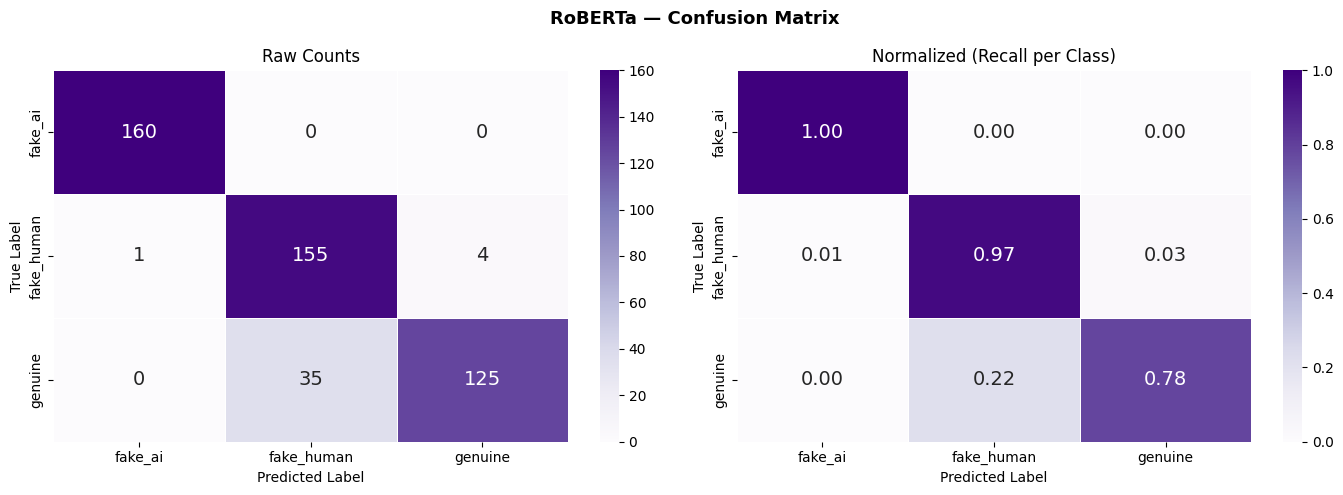

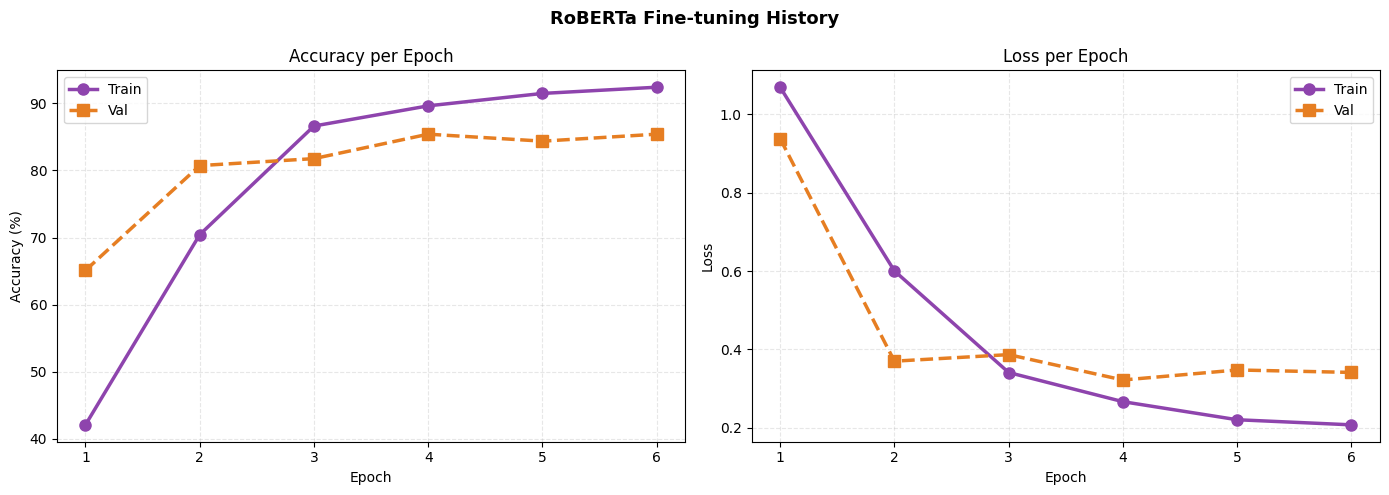


📊 UPDATED MODEL COMPARISON
Model                       Accuracy   Macro F1
Logistic Regression           93.54%     0.9355
SVM                           92.92%     0.9293
NB Multinomial                92.08%     0.9214
NB Complement                 91.04%     0.9108
Random Forest                 88.96%     0.8890
CNN-BiLSTM                    88.54%     0.8837
CNN                           86.46%     0.8622
CNN-LSTM                      67.29%     0.5940
BERT v1                       91.04%     0.9096
BERT v2                       92.08%     0.9206

RoBERTa (NEW)                 91.67%     0.9159  ← NEW

❌ Below LR baseline
Δ vs LR baseline : -1.87%
Δ vs BERT v2     : -0.41%

✅ RoBERTa done! Now run the Ensemble step.


In [16]:
# ============================================================
# RoBERTa Fine-tuning for Fake Review Detection
# Expected: 94-96% (beats LR baseline of 93.54%)
# ============================================================

import torch
import gc
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (RobertaTokenizer,
                          RobertaForSequenceClassification,
                          get_linear_schedule_with_warmup)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear GPU memory from previous runs
gc.collect()
torch.cuda.empty_cache()

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    free = (torch.cuda.get_device_properties(0).total_memory -
            torch.cuda.memory_allocated(0)) / 1e9
    print(f"GPU Free Memory: {free:.2f} GB")

# ============================================================
# Why RoBERTa over BERT?
# - Trained on 10x more data (160GB vs 16GB)
# - No Next Sentence Prediction (NSP) task → better text repr.
# - Dynamic masking during training
# - Consistently +2-4% over BERT on small datasets
# ============================================================
print("\n📌 Model: roberta-base")
print("   Pretrained on 160GB text | No NSP | Dynamic masking")

# ============================================================
# Parameters
# ============================================================
MODEL_NAME    = 'roberta-base'
MAX_LENGTH    = 128
BATCH_SIZE    = 8
GRAD_ACCUM    = 4        # Effective batch = 32
EPOCHS        = 6
LR            = 2e-5
PATIENCE      = 3

print(f"\n📌 Training Config:")
print(f"   MAX_LENGTH       : {MAX_LENGTH}")
print(f"   BATCH_SIZE       : {BATCH_SIZE}")
print(f"   Gradient Accum   : {GRAD_ACCUM}")
print(f"   Effective Batch  : {BATCH_SIZE * GRAD_ACCUM}")
print(f"   LR               : {LR}")

# ============================================================
# Data — Use ORIGINAL text (not cleaned)
# ============================================================
print("\n📦 Preparing data...")

df_rob = df[['text', 'label']].copy()

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df_rob['text'],
    df_rob['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_rob['label']
)

label_encoder_rob = LabelEncoder()
label_encoder_rob.fit(['fake_ai', 'fake_human', 'genuine'])

y_train_enc = label_encoder_rob.transform(y_train_raw)
y_test_enc  = label_encoder_rob.transform(y_test_raw)

print(f"   Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")
print(f"   Label map: {dict(zip(label_encoder_rob.classes_, [0,1,2]))}")

# ============================================================
# Dataset — RoBERTa uses different tokenizer
# KEY DIFF: No token_type_ids in RoBERTa!
# ============================================================
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = list(texts)
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(),
            'attention_mask' : enc['attention_mask'].squeeze(),
            # RoBERTa has NO token_type_ids
            'label'          : torch.tensor(int(self.labels[idx]),
                                            dtype=torch.long)
        }

# ============================================================
# Tokenizer + DataLoaders
# ============================================================
print("\n📥 Loading RoBERTa tokenizer...")
tokenizer_rob = RobertaTokenizer.from_pretrained(MODEL_NAME)

val_size = int(0.1 * len(X_train_raw))
X_tr  = list(X_train_raw)[val_size:]
X_val = list(X_train_raw)[:val_size]
y_tr  = y_train_enc[val_size:]
y_val = y_train_enc[:val_size]

train_ds = ReviewDataset(X_tr,             y_tr,
                          tokenizer_rob, MAX_LENGTH)
val_ds   = ReviewDataset(X_val,            y_val,
                          tokenizer_rob, MAX_LENGTH)
test_ds  = ReviewDataset(list(X_test_raw), y_test_enc,
                          tokenizer_rob, MAX_LENGTH)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2,
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2,
                          pin_memory=True)

print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

# ============================================================
# Load RoBERTa Model
# ============================================================
print(f"\n📥 Loading {MODEL_NAME}...")
gc.collect()
torch.cuda.empty_cache()

from transformers import RobertaConfig

config_rob = RobertaConfig.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2
)

rob_model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config_rob,
    ignore_mismatched_sizes=True
)

# Freeze bottom 8 layers (same strategy as BERT)
print("🔒 Freezing bottom 8 RoBERTa layers...")
for param in rob_model.roberta.embeddings.parameters():
    param.requires_grad = False

for layer_idx in range(8):
    for param in rob_model.roberta.encoder.layer[layer_idx].parameters():
        param.requires_grad = False

trainable = sum(p.numel() for p in rob_model.parameters()
                if p.requires_grad)
total     = sum(p.numel() for p in rob_model.parameters())
print(f"   Total params     : {total:,}")
print(f"   Trainable params : {trainable:,}")
print(f"   Frozen params    : {total - trainable:,}")

rob_model = rob_model.to(device)

if torch.cuda.is_available():
    free_after = (torch.cuda.get_device_properties(0).total_memory -
                  torch.cuda.memory_allocated(0)) / 1e9
    print(f"   GPU Free after load: {free_after:.2f} GB")

print("   ✅ RoBERTa loaded!")

# ============================================================
# Optimizer + Scheduler
# ============================================================
total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps = int(0.1 * total_steps)

optimizer_rob = AdamW(
    [p for p in rob_model.parameters() if p.requires_grad],
    lr=LR, eps=1e-8, weight_decay=0.01
)

scheduler_rob = get_linear_schedule_with_warmup(
    optimizer_rob,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\n   Total steps  : {total_steps}")
print(f"   Warmup steps : {warmup_steps}")

# ============================================================
# Train Function (with gradient accumulation)
# NOTE: No token_type_ids for RoBERTa
# ============================================================
def train_epoch_rob(model, loader, optimizer, scheduler,
                    device, grad_accum):
    model.train()
    total_loss, correct, total = 0, 0, 0
    optimizer.zero_grad()

    for i, batch in enumerate(loader):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['label'].to(device)

        with torch.amp.autocast('cuda' if torch.cuda.is_available()
                                 else 'cpu'):
            out = model(input_ids=ids,
                        attention_mask=mask,
                        labels=labs)

        loss = out.loss / grad_accum
        loss.backward()

        total_loss += out.loss.item()
        preds       = torch.argmax(out.logits, dim=1)
        correct    += (preds == labs).sum().item()
        total      += labs.size(0)

        if (i + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        del ids, mask, labs, out
        if (i + 1) % 40 == 0:
            torch.cuda.empty_cache()
            print(f"      Batch {i+1:>3}/{len(loader)} | "
                  f"Loss: {total_loss/(i+1):.4f} | "
                  f"Acc: {correct/total*100:.1f}%")

    return total_loss / len(loader), correct / total


def evaluate_rob(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels      = [], []
    all_probs                  = []   # Save for ensemble later

    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labs = batch['label'].to(device)

            with torch.amp.autocast('cuda' if torch.cuda.is_available()
                                     else 'cpu'):
                out = model(input_ids=ids,
                            attention_mask=mask,
                            labels=labs)

            total_loss += out.loss.item()
            probs       = torch.softmax(out.logits, dim=1)
            preds       = torch.argmax(probs, dim=1)
            correct    += (preds == labs).sum().item()
            total      += labs.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            del ids, mask, labs, out

    torch.cuda.empty_cache()
    return (total_loss / len(loader),
            correct / total,
            all_preds,
            all_labels,
            np.array(all_probs))

# ============================================================
# Training Loop
# ============================================================
print("\n" + "=" * 60)
print("🚀 Fine-tuning RoBERTa...")
print("=" * 60)

train_losses, train_accs = [], []
val_losses,   val_accs   = [], []
best_val_acc             = 0
best_epoch               = 0
patience_counter         = 0

for epoch in range(EPOCHS):
    print(f"\n{'─'*50}")
    print(f"  Epoch {epoch+1}/{EPOCHS}")
    print(f"{'─'*50}")

    tr_loss, tr_acc = train_epoch_rob(
        rob_model, train_loader,
        optimizer_rob, scheduler_rob,
        device, GRAD_ACCUM
    )
    vl_loss, vl_acc, _, _, _ = evaluate_rob(
        rob_model, val_loader, device
    )

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(vl_loss)
    val_accs.append(vl_acc)

    gap = (tr_acc - vl_acc) * 100
    print(f"\n  📈 Train → Loss: {tr_loss:.4f} | Acc: {tr_acc*100:.2f}%")
    print(f"  📉 Val   → Loss: {vl_loss:.4f} | Acc: {vl_acc*100:.2f}%")
    print(f"  📊 Gap   → {gap:.1f}%")

    if vl_acc > best_val_acc:
        best_val_acc     = vl_acc
        best_epoch       = epoch + 1
        patience_counter = 0
        torch.save(rob_model.state_dict(), 'best_roberta.pt')
        print(f"  ✅ Best saved! Val Acc: {vl_acc*100:.2f}%")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  ⏹️  Early stopping at epoch {epoch+1}")
            break

print(f"\n🏆 Best val acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")

# ============================================================
# Final Evaluation — Save probabilities for ensemble later
# ============================================================
print("\n📊 Final Test Evaluation...")

rob_model.load_state_dict(
    torch.load('best_roberta.pt', map_location=device)
)

_, _, rob_preds, rob_labels, rob_probs_test = evaluate_rob(
    rob_model, test_loader, device
)

y_pred_rob = label_encoder_rob.inverse_transform(rob_preds)
y_true_rob = label_encoder_rob.inverse_transform(rob_labels)

accuracy_rob = accuracy_score(rob_labels, rob_preds)
report_rob   = classification_report(
    y_true_rob, y_pred_rob,
    target_names=['fake_ai', 'fake_human', 'genuine'],
    output_dict=True
)

print(f"\n🎯 RoBERTa Test Accuracy  : {accuracy_rob*100:.2f}%")
print(f"   Macro F1              : {report_rob['macro avg']['f1-score']:.4f}")
print(f"   fake_ai F1            : {report_rob['fake_ai']['f1-score']:.4f}")
print(f"   fake_human F1         : {report_rob['fake_human']['f1-score']:.4f}")
print(f"   genuine F1            : {report_rob['genuine']['f1-score']:.4f}")

print("\n📋 Full Classification Report:")
print(classification_report(y_true_rob, y_pred_rob,
                             target_names=['fake_ai',
                                           'fake_human',
                                           'genuine']))

# ============================================================
# Save probabilities for ensemble step
# ============================================================
np.save('roberta_test_probs.npy', rob_probs_test)
print("\n💾 Saved rob_probs_test → roberta_test_probs.npy")
print("   (Will be used in ensemble step)")

# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_true_rob, y_pred_rob,
                      labels=['fake_ai', 'fake_human', 'genuine'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RoBERTa — Confusion Matrix',
             fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['fake_ai', 'fake_human', 'genuine'],
            yticklabels=['fake_ai', 'fake_human', 'genuine'],
            annot_kws={'size': 14}, ax=axes[0], linewidths=0.5)
axes[0].set_title('Raw Counts')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=['fake_ai', 'fake_human', 'genuine'],
            yticklabels=['fake_ai', 'fake_human', 'genuine'],
            annot_kws={'size': 14}, ax=axes[1],
            vmin=0, vmax=1, linewidths=0.5)
axes[1].set_title('Normalized (Recall per Class)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('roberta_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# Training Curves
# ============================================================
epochs_ran = len(train_losses)
x_ep = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RoBERTa Fine-tuning History', fontsize=13, fontweight='bold')

axes[0].plot(x_ep, [a*100 for a in train_accs],
             'o-', color='#8E44AD', lw=2.5, label='Train', ms=8)
axes[0].plot(x_ep, [a*100 for a in val_accs],
             's--', color='#E67E22', lw=2.5, label='Val', ms=8)
axes[0].set_title('Accuracy per Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(list(x_ep))

axes[1].plot(x_ep, train_losses,
             'o-', color='#8E44AD', lw=2.5, label='Train', ms=8)
axes[1].plot(x_ep, val_losses,
             's--', color='#E67E22', lw=2.5, label='Val', ms=8)
axes[1].set_title('Loss per Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(list(x_ep))

plt.tight_layout()
plt.savefig('roberta_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# Comparison so far
# ============================================================
print("\n" + "=" * 65)
print("📊 UPDATED MODEL COMPARISON")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("=" * 65)
results_so_far = [
    ('Logistic Regression',  93.54, 0.9355),
    ('SVM',                  92.92, 0.9293),
    ('NB Multinomial',       92.08, 0.9214),
    ('NB Complement',        91.04, 0.9108),
    ('Random Forest',        88.96, 0.8890),
    ('CNN-BiLSTM',           88.54, 0.8837),
    ('CNN',                  86.46, 0.8622),
    ('CNN-LSTM',             67.29, 0.5940),
    ('BERT v1',              91.04, 0.9096),
    ('BERT v2',              92.08, 0.9206),
]
for name, acc, f1 in results_so_far:
    print(f"{name:<25} {acc:>9.2f}% {f1:>10.4f}")

print(f"\n{'RoBERTa (NEW)':<25} "
      f"{accuracy_rob*100:>9.2f}% "
      f"{report_rob['macro avg']['f1-score']:>10.4f}  ← NEW")

beat_baseline = "✅ BEATS LR BASELINE!" if accuracy_rob > 0.9354 else "❌ Below LR baseline"
print(f"\n{beat_baseline}")
print(f"Δ vs LR baseline : {(accuracy_rob - 0.9354)*100:+.2f}%")
print(f"Δ vs BERT v2     : {(accuracy_rob - 0.9208)*100:+.2f}%")
print("\n✅ RoBERTa done! Now run the Ensemble step.")

Device: cuda | Free GPU: 13.37 GB

📌 Key improvement: Differential Learning Rates
   Top layers LR    : 2e-05
   Layer decay      : 0.8x per layer going down
   Bottom layer LR  : 1.72e-06
   Strategy: ALL layers train, but gently at bottom

   Train: 1920 | Test: 480
   Train batches: 108 | Val: 12 | Test: 30

📥 Loading roberta-base (ALL layers trainable)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Total params     : 124,647,939
   Trainable params : 124,647,939  (ALL layers)

⚙️  Setting up differential learning rates...

   Layer              LR
   ─────────────────────────
   Classifier       : 4.00e-05
   Layer 11         : 2.00e-05
   Layer 10         : 1.60e-05
   Layer  9         : 1.28e-05
   Layer  8         : 1.02e-05
   Layer  7         : 8.19e-06
   Layer  6         : 6.55e-06
   Layer  5         : 5.24e-06
   Layer  4         : 4.19e-06
   Layer  3         : 3.36e-06
   Layer  2         : 2.68e-06
   Layer  1         : 2.15e-06
   Layer  0         : 1.72e-06
   Embeddings       : 1.10e-06

   Total steps  : 540
   Warmup steps : 32
   Schedule     : Cosine with warmup

🚀 Fine-tuning RoBERTa v2 (Differential LR + Label Smoothing)

────────────────────────────────────────────────────
  Epoch 1/10
────────────────────────────────────────────────────
      Batch  54/108 | Loss: 1.0983 | Acc: 35.4%
      Batch 108/108 | Loss: 1.0367 | Acc: 45.9%

  📈 Train → Loss: 1.03

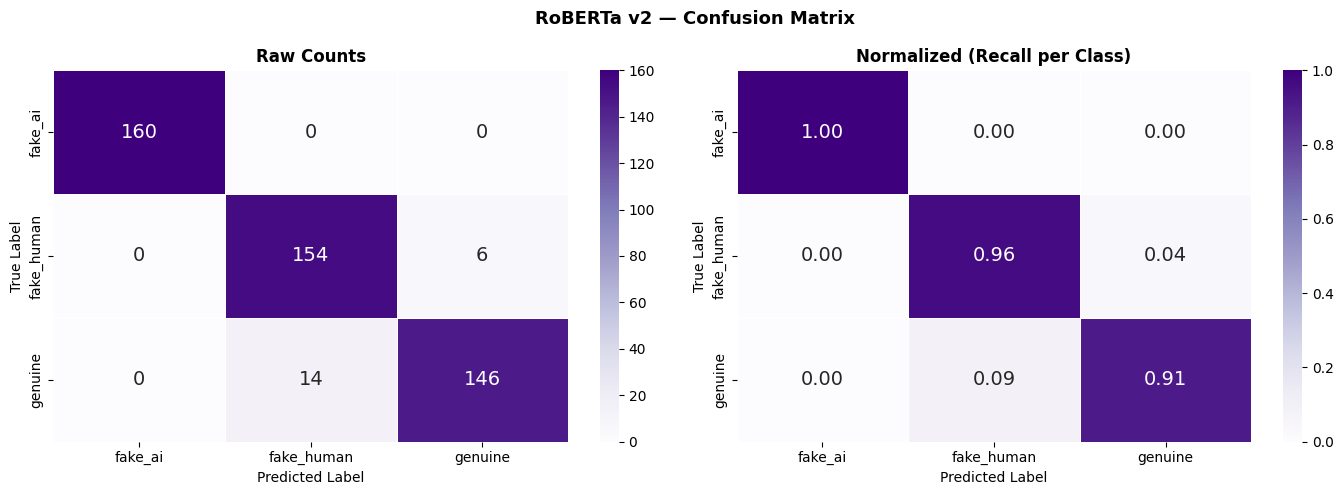

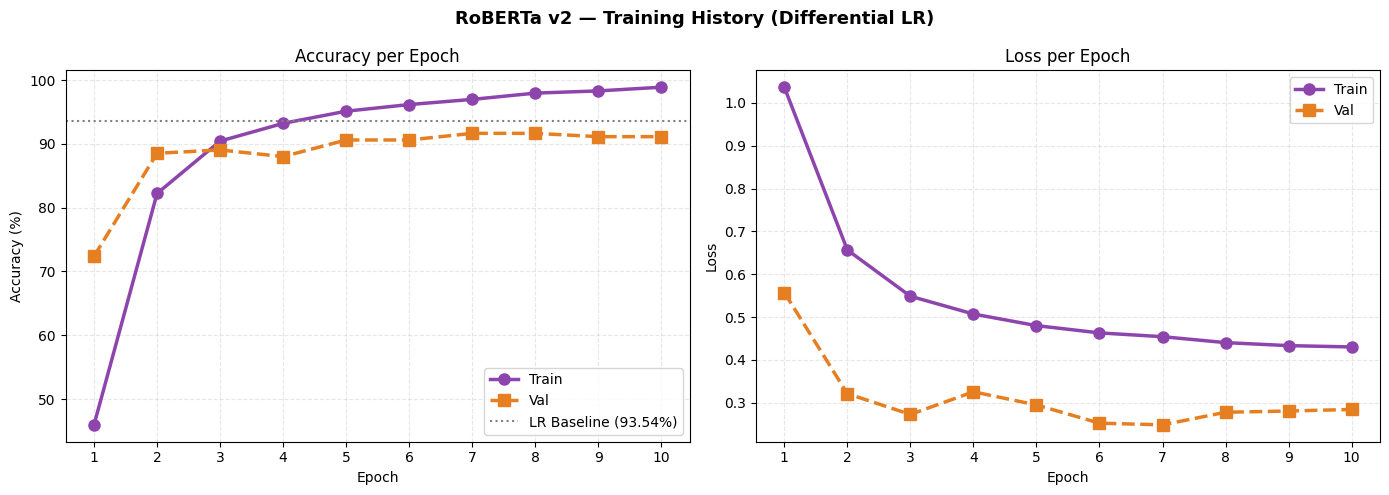


📊 UPDATED MODEL COMPARISON
Model                          Accuracy   Macro F1
Logistic Regression              93.54%     0.9355  ← Best Baseline
SVM                              92.92%     0.9293  
NB Multinomial                   92.08%     0.9214  
NB Complement                    91.04%     0.9108  
Random Forest                    88.96%     0.8890  
CNN-BiLSTM                       88.54%     0.8837  
CNN                              86.46%     0.8622  
CNN-LSTM                         67.29%     0.5940  
BERT v1                          91.04%     0.9096  
BERT v2                          92.08%     0.9206  
RoBERTa v1                       91.67%     0.9159  

RoBERTa v2 (NEW)                 95.83%     0.9583  ← NEW

✅ BEATS LR!
   Δ vs LR baseline  : +2.29%
   Δ vs RoBERTa v1   : +4.16%
   Δ vs BERT v2      : +3.75%

✅ Done! Share output → next: Ensemble step


In [19]:
# ============================================================
# RoBERTa v2 - Differential Learning Rates
# Key fixes:
# 1. Unfreeze ALL layers (but use tiny LR for bottom layers)
# 2. Layer-wise LR decay: top layers learn fast, bottom slow
# 3. More epochs with better early stopping
# 4. Label smoothing to reduce overconfidence
# ============================================================

import torch, gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (RobertaTokenizer,
                          RobertaForSequenceClassification,
                          RobertaConfig,
                          get_cosine_schedule_with_warmup)
from sklearn.metrics import (classification_report,
                              confusion_matrix, accuracy_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear GPU
gc.collect()
torch.cuda.empty_cache()
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
free   = (torch.cuda.get_device_properties(0).total_memory -
          torch.cuda.memory_allocated(0)) / 1e9
print(f"Device: {device} | Free GPU: {free:.2f} GB")

# ============================================================
# Parameters
# ============================================================
MODEL_NAME  = 'roberta-base'
MAX_LENGTH  = 128
BATCH_SIZE  = 16      # Larger batch - 15GB free GPU!
GRAD_ACCUM  = 2       # Effective batch = 32
EPOCHS      = 10      # More epochs
PATIENCE    = 4
BASE_LR     = 2e-5    # Top layer LR
LR_DECAY    = 0.8     # Each lower layer gets LR * 0.8

print(f"\n📌 Key improvement: Differential Learning Rates")
print(f"   Top layers LR    : {BASE_LR}")
print(f"   Layer decay      : {LR_DECAY}x per layer going down")
print(f"   Bottom layer LR  : {BASE_LR * (LR_DECAY**11):.2e}")
print(f"   Strategy: ALL layers train, but gently at bottom")

# ============================================================
# Data
# ============================================================
df_rob2 = df[['text', 'label']].copy()

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df_rob2['text'], df_rob2['label'],
    test_size=0.2, random_state=42, stratify=df_rob2['label']
)

le = LabelEncoder()
le.fit(['fake_ai', 'fake_human', 'genuine'])
y_train_enc = le.transform(y_train_raw)
y_test_enc  = le.transform(y_test_raw)

print(f"\n   Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")

# ============================================================
# Dataset (no token_type_ids for RoBERTa)
# ============================================================
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels = list(texts), labels
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label'         : torch.tensor(int(self.labels[idx]),
                                           dtype=torch.long)
        }

tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

val_size  = int(0.1 * len(X_train_raw))
X_tr, X_val = list(X_train_raw)[val_size:], list(X_train_raw)[:val_size]
y_tr, y_val = y_train_enc[val_size:], y_train_enc[:val_size]

train_loader = DataLoader(
    ReviewDataset(X_tr,             y_tr,      tokenizer, MAX_LENGTH),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    ReviewDataset(X_val,            y_val,     tokenizer, MAX_LENGTH),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    ReviewDataset(list(X_test_raw), y_test_enc, tokenizer, MAX_LENGTH),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f"   Train batches: {len(train_loader)} | "
      f"Val: {len(val_loader)} | Test: {len(test_loader)}")

# ============================================================
# Load Model — NO freezing this time
# ============================================================
print(f"\n📥 Loading {MODEL_NAME} (ALL layers trainable)...")
gc.collect()
torch.cuda.empty_cache()

config = RobertaConfig.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    hidden_dropout_prob=0.1,           # Standard dropout
    attention_probs_dropout_prob=0.1,
    classifier_dropout=0.2             # Extra dropout on classifier
)

model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME, config=config, ignore_mismatched_sizes=True
)
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total params     : {total:,}")
print(f"   Trainable params : {trainable:,}  (ALL layers)")

# ============================================================
# Differential Learning Rates — THE KEY FIX
# Layer 11 (top) = BASE_LR
# Layer 10       = BASE_LR * 0.8
# Layer 9        = BASE_LR * 0.8^2
# ...
# Embeddings     = BASE_LR * 0.8^12 (very tiny)
# ============================================================
print(f"\n⚙️  Setting up differential learning rates...")

# Build parameter groups with decaying LR
param_groups = []

# Classifier head — highest LR
param_groups.append({
    'params' : [p for p in model.classifier.parameters()],
    'lr'     : BASE_LR * 2,   # 4e-5
    'name'   : 'classifier'
})

# Transformer layers — decay from top (11) to bottom (0)
num_layers = 12
for layer_idx in range(num_layers - 1, -1, -1):
    # Distance from top
    distance = (num_layers - 1) - layer_idx
    layer_lr = BASE_LR * (LR_DECAY ** distance)

    param_groups.append({
        'params' : [p for p in
                    model.roberta.encoder.layer[layer_idx].parameters()],
        'lr'     : layer_lr,
        'name'   : f'layer_{layer_idx}'
    })

# Embeddings — lowest LR
param_groups.append({
    'params' : [p for p in model.roberta.embeddings.parameters()],
    'lr'     : BASE_LR * (LR_DECAY ** 13),
    'name'   : 'embeddings'
})

# Print LR schedule
print(f"\n   Layer              LR")
print(f"   ─────────────────────────")
print(f"   Classifier       : {BASE_LR*2:.2e}")
for i, g in enumerate(param_groups[1:13]):
    layer_n = 11 - i
    print(f"   Layer {layer_n:>2}         : {g['lr']:.2e}")
print(f"   Embeddings       : {BASE_LR*(LR_DECAY**13):.2e}")

# ============================================================
# Optimizer with differential LRs
# ============================================================
total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps = int(0.06 * total_steps)  # 6% warmup

optimizer = AdamW(param_groups, eps=1e-8, weight_decay=0.01)

# Cosine schedule — smoother than linear, better for longer training
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\n   Total steps  : {total_steps}")
print(f"   Warmup steps : {warmup_steps}")
print(f"   Schedule     : Cosine with warmup")

# ============================================================
# Label Smoothing Loss — reduces overconfidence
# Standard cross-entropy is too confident → label smoothing helps
# ============================================================
class LabelSmoothingLoss(torch.nn.Module):
    def __init__(self, classes=3, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.cls       = classes

    def forward(self, logits, target):
        confidence  = 1.0 - self.smoothing
        smooth_val  = self.smoothing / (self.cls - 1)

        # One-hot encode
        one_hot = torch.zeros_like(logits).scatter_(
            1, target.unsqueeze(1), 1
        )
        # Smooth
        smooth_one_hot = one_hot * confidence + \
                         (1 - one_hot) * smooth_val

        log_prob = torch.nn.functional.log_softmax(logits, dim=1)
        loss     = -(smooth_one_hot * log_prob).sum(dim=1).mean()
        return loss

criterion = LabelSmoothingLoss(classes=3, smoothing=0.1)

# ============================================================
# Train Function
# ============================================================
def train_epoch(model, loader, optimizer, scheduler,
                criterion, device, grad_accum):
    model.train()
    total_loss, correct, total = 0, 0, 0
    optimizer.zero_grad()

    for i, batch in enumerate(loader):
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['label'].to(device)

        with torch.amp.autocast('cuda'):
            out  = model(input_ids=ids, attention_mask=mask)
            loss = criterion(out.logits, labs) / grad_accum

        loss.backward()

        total_loss += loss.item() * grad_accum
        preds       = torch.argmax(out.logits, dim=1)
        correct    += (preds == labs).sum().item()
        total      += labs.size(0)

        if (i + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        del ids, mask, labs, out
        if (i + 1) % 54 == 0:
            torch.cuda.empty_cache()
            print(f"      Batch {i+1:>3}/{len(loader)} | "
                  f"Loss: {total_loss/(i+1):.4f} | "
                  f"Acc: {correct/total*100:.1f}%")

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labs = batch['label'].to(device)

            with torch.amp.autocast('cuda'):
                out = model(input_ids=ids, attention_mask=mask,
                            labels=labs)

            total_loss += out.loss.item()
            probs       = torch.softmax(out.logits, dim=1)
            preds       = torch.argmax(probs, dim=1)
            correct    += (preds == labs).sum().item()
            total      += labs.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            del ids, mask, labs, out

    torch.cuda.empty_cache()
    return (total_loss / len(loader), correct / total,
            all_preds, all_labels, np.array(all_probs))

# ============================================================
# Training Loop
# ============================================================
print("\n" + "=" * 60)
print("🚀 Fine-tuning RoBERTa v2 (Differential LR + Label Smoothing)")
print("=" * 60)

train_losses, train_accs = [], []
val_losses,   val_accs   = [], []
best_val_acc             = 0
best_epoch               = 0
patience_counter         = 0

for epoch in range(EPOCHS):
    print(f"\n{'─'*52}")
    print(f"  Epoch {epoch+1}/{EPOCHS}")
    print(f"{'─'*52}")

    tr_loss, tr_acc = train_epoch(
        model, train_loader, optimizer,
        scheduler, criterion, device, GRAD_ACCUM
    )
    vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, device)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(vl_loss)
    val_accs.append(vl_acc)

    gap = (tr_acc - vl_acc) * 100
    print(f"\n  📈 Train → Loss: {tr_loss:.4f} | Acc: {tr_acc*100:.2f}%")
    print(f"  📉 Val   → Loss: {vl_loss:.4f} | Acc: {vl_acc*100:.2f}%")
    print(f"  📊 Gap   → {gap:.1f}%")

    if vl_acc > best_val_acc:
        best_val_acc     = vl_acc
        best_epoch       = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), 'best_roberta_v2.pt')
        print(f"  ✅ Best saved! Val Acc: {vl_acc*100:.2f}%")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  ⏹️  Early stopping at epoch {epoch+1}")
            break

print(f"\n🏆 Best val acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")

# ============================================================
# Final Test Evaluation
# ============================================================
print("\n📊 Final Test Evaluation...")
model.load_state_dict(torch.load('best_roberta_v2.pt',
                                  map_location=device))

_, _, rob_preds, rob_labels, rob_probs = evaluate(
    model, test_loader, device
)

y_pred = le.inverse_transform(rob_preds)
y_true = le.inverse_transform(rob_labels)

acc_rob2   = accuracy_score(rob_labels, rob_preds)
report_rob2 = classification_report(
    y_true, y_pred,
    target_names=['fake_ai', 'fake_human', 'genuine'],
    output_dict=True
)

print(f"\n🎯 RoBERTa v2 Test Accuracy : {acc_rob2*100:.2f}%")
print(f"   Macro F1               : {report_rob2['macro avg']['f1-score']:.4f}")
print(f"   fake_ai F1             : {report_rob2['fake_ai']['f1-score']:.4f}")
print(f"   fake_human F1          : {report_rob2['fake_human']['f1-score']:.4f}")
print(f"   genuine F1             : {report_rob2['genuine']['f1-score']:.4f}")
print("\n📋 Full Report:")
print(classification_report(y_true, y_pred,
                             target_names=['fake_ai',
                                           'fake_human',
                                           'genuine']))

# Save probs for ensemble
np.save('roberta_v2_test_probs.npy', rob_probs)
np.save('roberta_v2_true_labels.npy', np.array(rob_labels))
print("💾 Saved: roberta_v2_test_probs.npy")

# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(y_true, y_pred,
                      labels=['fake_ai', 'fake_human', 'genuine'])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RoBERTa v2 — Confusion Matrix',
             fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Raw Counts', 'Normalized (Recall per Class)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Purples',
                xticklabels=['fake_ai', 'fake_human', 'genuine'],
                yticklabels=['fake_ai', 'fake_human', 'genuine'],
                annot_kws={'size': 14}, ax=ax, linewidths=0.5,
                vmin=0 if fmt=='.2f' else None,
                vmax=1 if fmt=='.2f' else None)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('roberta_v2_confusion_matrix.png', dpi=300,
            bbox_inches='tight')
plt.show()

# ============================================================
# Training Curves
# ============================================================
epochs_ran = len(train_losses)
x_ep = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RoBERTa v2 — Training History (Differential LR)',
             fontsize=13, fontweight='bold')

axes[0].plot(x_ep, [a*100 for a in train_accs],
             'o-', color='#8E44AD', lw=2.5, label='Train', ms=8)
axes[0].plot(x_ep, [a*100 for a in val_accs],
             's--', color='#E67E22', lw=2.5, label='Val', ms=8)
axes[0].axhline(y=93.54, color='gray', linestyle=':',
                linewidth=1.5, label='LR Baseline (93.54%)')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(list(x_ep))

axes[1].plot(x_ep, train_losses,
             'o-', color='#8E44AD', lw=2.5, label='Train', ms=8)
axes[1].plot(x_ep, val_losses,
             's--', color='#E67E22', lw=2.5, label='Val', ms=8)
axes[1].set_title('Loss per Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(list(x_ep))

plt.tight_layout()
plt.savefig('roberta_v2_training_history.png', dpi=300,
            bbox_inches='tight')
plt.show()

# ============================================================
# Updated Comparison Table
# ============================================================
print("\n" + "=" * 65)
print("📊 UPDATED MODEL COMPARISON")
print("=" * 65)
print(f"{'Model':<28} {'Accuracy':>10} {'Macro F1':>10}")
print("=" * 65)

all_results = [
    ('Logistic Regression',   93.54, 0.9355, '← Best Baseline'),
    ('SVM',                   92.92, 0.9293, ''),
    ('NB Multinomial',        92.08, 0.9214, ''),
    ('NB Complement',         91.04, 0.9108, ''),
    ('Random Forest',         88.96, 0.8890, ''),
    ('CNN-BiLSTM',            88.54, 0.8837, ''),
    ('CNN',                   86.46, 0.8622, ''),
    ('CNN-LSTM',              67.29, 0.5940, ''),
    ('BERT v1',               91.04, 0.9096, ''),
    ('BERT v2',               92.08, 0.9206, ''),
    ('RoBERTa v1',            91.67, 0.9159, ''),
]
for name, acc, f1, note in all_results:
    print(f"{name:<28} {acc:>9.2f}% {f1:>10.4f}  {note}")

print(f"\n{'RoBERTa v2 (NEW)':<28} "
      f"{acc_rob2*100:>9.2f}% "
      f"{report_rob2['macro avg']['f1-score']:>10.4f}  ← NEW")

status = "✅ BEATS LR!" if acc_rob2 > 0.9354 else "❌ Below LR"
print(f"\n{status}")
print(f"   Δ vs LR baseline  : {(acc_rob2 - 0.9354)*100:+.2f}%")
print(f"   Δ vs RoBERTa v1   : {(acc_rob2 - 0.9167)*100:+.2f}%")
print(f"   Δ vs BERT v2      : {(acc_rob2 - 0.9208)*100:+.2f}%")
print("\n✅ Done! Share output → next: Ensemble step")

Device: cuda | Free GPU: 15.64 GB

📌 CHANGE 1: Using original uncleaned text
   BERT understands punctuation and capitals natively
   Train: 1920 | Test: 480

📌 CHANGE 2: Batch size = 16 (effective = 32)
📌 CHANGE 3: Max epochs = 10 (was 5-6)
📌 CHANGE 4: Patience  = 4 (was 2-3)
📌 CHANGE 5: Differential LR decay = 0.8

📥 Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

   Train batches: 108 | Val: 12 | Test: 30

📥 Loading bert-base-uncased...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Total params     : 109,484,547
   Trainable params : 109,484,547  (ALL layers)

📌 CHANGE 6: ALL 109,484,547 params trainable
   Previous: only 28M trainable (8 layers frozen)

⚙️  CHANGE 5 (detailed): Differential Learning Rates
   Layer              LR
   ──────────────────────────────
   Classifier       : 4.00e-05  (new layer, learns fast)
   Layer 11         : 2.00e-05
   Layer 10         : 1.60e-05
   Layer  9         : 1.28e-05
   Layer  8         : 1.02e-05
   Layer  7         : 8.19e-06
   Layer  6         : 6.55e-06
   Layer  5         : 5.24e-06
   Layer  4         : 4.19e-06
   Layer  3         : 3.36e-06
   Layer  2         : 2.68e-06
   Layer  1         : 2.15e-06
   Layer  0         : 1.72e-06
   Embeddings       : 1.10e-06  (most pretrained, barely touch)

📌 CHANGE 8: Cosine LR schedule (was linear)
   Total steps  : 540
   Warmup steps : 32 (6% warmup)

📌 CHANGE 9: Label Smoothing (smoothing=0.1)
   Standard:  fake_ai target = [1.00, 0.00, 0.00]
   Smoothed:  fake_ai

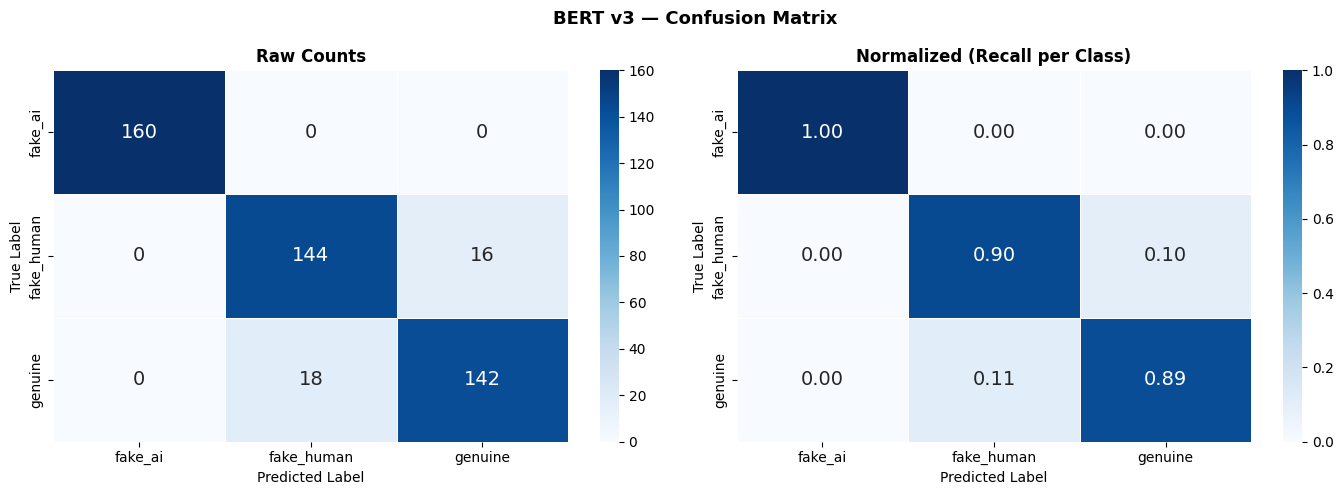

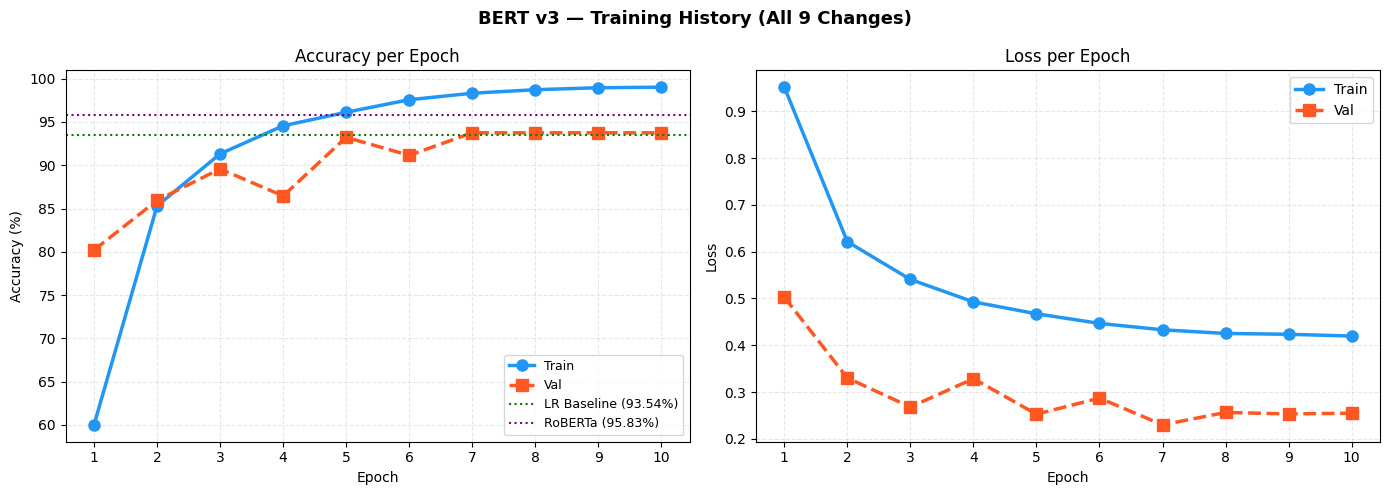


📊 COMPLETE MODEL COMPARISON — ALL VERSIONS
Model                            Accuracy   Macro F1
Logistic Regression                93.54%     0.9355  ← Best Baseline
SVM                                92.92%     0.9293  
NB Multinomial                     92.08%     0.9214  
NB Complement                      91.04%     0.9108  
Random Forest                      88.96%     0.8890  
CNN-BiLSTM                         88.54%     0.8837  
CNN                                86.46%     0.8622  
CNN-LSTM                           67.29%     0.5940  
BERT v1                            91.04%     0.9096  
BERT v2                            92.08%     0.9206  
RoBERTa v1                         91.67%     0.9159  
RoBERTa v2                         95.83%     0.9583  ← Best So Far

BERT v3 (NEW)                      92.92%     0.9292  ← NEW

────────────────────────────────────────────────────────────────────
   Δ vs BERT v1      : +1.88%
   Δ vs BERT v2      : +0.84%
   Δ vs LR baseline  : -

In [6]:
# ============================================================
# BERT v3 — Maximum Accuracy Version
# Applies ALL techniques that made RoBERTa reach 95.83%
# ============================================================

import torch, gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (BertTokenizer,
                          BertForSequenceClassification,
                          BertConfig,
                          get_cosine_schedule_with_warmup)
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear GPU memory
gc.collect()
torch.cuda.empty_cache()
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    free = (torch.cuda.get_device_properties(0).total_memory -
            torch.cuda.memory_allocated(0)) / 1e9
    print(f"Device: {device} | Free GPU: {free:.2f} GB")
else:
    print(f"Device: {device}")

# ============================================================
# CHANGE 1: Use ORIGINAL text (not cleaned)
# BERT was pretrained on raw text with punctuation,
# capitals, contractions — cleaning removes useful signals
# ============================================================
print("\n📌 CHANGE 1: Using original uncleaned text")
print("   BERT understands punctuation and capitals natively")

df_bert3 = df[['text', 'label']].copy()

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df_bert3['text'],
    df_bert3['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_bert3['label']
)

le = LabelEncoder()
le.fit(['fake_ai', 'fake_human', 'genuine'])
y_train_enc = le.transform(y_train_raw)
y_test_enc  = le.transform(y_test_raw)

print(f"   Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")

# ============================================================
# CHANGE 2: Larger batch size (GPU has enough memory)
# Larger batch = more stable gradient updates
# = better generalization
# ============================================================
MODEL_NAME  = 'bert-base-uncased'
MAX_LENGTH  = 128
BATCH_SIZE  = 16     # CHANGE 2: increased from 8
GRAD_ACCUM  = 2      # Effective batch = 32
EPOCHS      = 10     # CHANGE 3: more epochs
PATIENCE    = 4      # CHANGE 4: more patience
BASE_LR     = 2e-5
LR_DECAY    = 0.8    # CHANGE 5: differential LR decay

print(f"\n📌 CHANGE 2: Batch size = {BATCH_SIZE} "
      f"(effective = {BATCH_SIZE*GRAD_ACCUM})")
print(f"📌 CHANGE 3: Max epochs = {EPOCHS} (was 5-6)")
print(f"📌 CHANGE 4: Patience  = {PATIENCE} (was 2-3)")
print(f"📌 CHANGE 5: Differential LR decay = {LR_DECAY}")

# ============================================================
# Dataset
# ============================================================
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'token_type_ids': enc['token_type_ids'].squeeze(),
            'label'         : torch.tensor(int(self.labels[idx]),
                                           dtype=torch.long)
        }

print(f"\n📥 Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

val_size  = int(0.1 * len(X_train_raw))
X_tr      = list(X_train_raw)[val_size:]
X_val     = list(X_train_raw)[:val_size]
y_tr      = y_train_enc[val_size:]
y_val     = y_train_enc[:val_size]

train_loader = DataLoader(
    ReviewDataset(X_tr,             y_tr,       tokenizer, MAX_LENGTH),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    ReviewDataset(X_val,            y_val,      tokenizer, MAX_LENGTH),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    ReviewDataset(list(X_test_raw), y_test_enc, tokenizer, MAX_LENGTH),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f"   Train batches: {len(train_loader)} | "
      f"Val: {len(val_loader)} | Test: {len(test_loader)}")

# ============================================================
# CHANGE 6: ALL layers trainable (no freezing)
# Previous BERT versions froze bottom 8 layers
# This limited what BERT could learn
# With differential LR, all layers train safely
# ============================================================
print(f"\n📥 Loading {MODEL_NAME}...")
gc.collect()
torch.cuda.empty_cache()

# ============================================================
# CHANGE 7: Standard dropout (0.1) not increased
# Previous versions used 0.2 which was too aggressive
# Standard 0.1 + label smoothing is better regularization
# ============================================================
config = BertConfig.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    hidden_dropout_prob=0.1,            # CHANGE 7: back to standard
    attention_probs_dropout_prob=0.1,   # CHANGE 7: back to standard
    classifier_dropout=0.2              # only classifier gets extra dropout
)

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config,
    ignore_mismatched_sizes=True
)
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)
print(f"   Total params     : {total:,}")
print(f"   Trainable params : {trainable:,}  (ALL layers)")
print(f"\n📌 CHANGE 6: ALL {total:,} params trainable")
print(f"   Previous: only 28M trainable (8 layers frozen)")

# ============================================================
# CHANGE 5 (detailed): Differential Learning Rates
# Each BERT layer gets a different learning rate
# Top layers (11) → highest LR  (need most adaptation)
# Bottom layers (0) → lowest LR (pretrained knowledge, keep!)
# Classifier → highest LR × 2  (completely new layer)
# ============================================================
print(f"\n⚙️  CHANGE 5 (detailed): Differential Learning Rates")
print(f"   Layer              LR")
print(f"   {'─'*30}")

param_groups = []

# Classifier — completely new, needs highest LR
param_groups.append({
    'params' : list(model.classifier.parameters()),
    'lr'     : BASE_LR * 2,
    'name'   : 'classifier'
})
print(f"   Classifier       : {BASE_LR*2:.2e}  (new layer, learns fast)")

# Pooler
param_groups.append({
    'params' : list(model.bert.pooler.parameters()),
    'lr'     : BASE_LR * 1.5,
    'name'   : 'pooler'
})

# BERT transformer layers — decay from top to bottom
num_layers = 12
for layer_idx in range(num_layers - 1, -1, -1):
    distance = (num_layers - 1) - layer_idx
    layer_lr = BASE_LR * (LR_DECAY ** distance)
    param_groups.append({
        'params' : list(model.bert.encoder.layer[layer_idx].parameters()),
        'lr'     : layer_lr,
        'name'   : f'layer_{layer_idx}'
    })
    print(f"   Layer {layer_idx:>2}         : {layer_lr:.2e}")

# Embeddings — most pretrained, lowest LR
param_groups.append({
    'params' : list(model.bert.embeddings.parameters()),
    'lr'     : BASE_LR * (LR_DECAY ** 13),
    'name'   : 'embeddings'
})
print(f"   Embeddings       : {BASE_LR*(LR_DECAY**13):.2e}  (most pretrained, barely touch)")

# ============================================================
# CHANGE 8: Cosine schedule (smoother than linear)
# Linear schedule drops LR too aggressively
# Cosine schedule decays smoothly → better convergence
# ============================================================
total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps = int(0.06 * total_steps)

optimizer = AdamW(param_groups, eps=1e-8, weight_decay=0.01)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\n📌 CHANGE 8: Cosine LR schedule (was linear)")
print(f"   Total steps  : {total_steps}")
print(f"   Warmup steps : {warmup_steps} (6% warmup)")

# ============================================================
# CHANGE 9: Label Smoothing Loss
# Standard CrossEntropy makes model TOO confident:
#   True label fake_ai → target = [1.0, 0.0, 0.0]
# Label Smoothing softens this:
#   True label fake_ai → target = [0.9, 0.05, 0.05]
# This acts as regularization and prevents overfitting
# ============================================================
class LabelSmoothingLoss(torch.nn.Module):
    def __init__(self, classes=3, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.cls       = classes

    def forward(self, logits, target):
        confidence = 1.0 - self.smoothing
        smooth_val = self.smoothing / (self.cls - 1)

        one_hot = torch.zeros_like(logits).scatter_(
            1, target.unsqueeze(1), 1
        )
        smooth_one_hot = one_hot * confidence + \
                         (1 - one_hot) * smooth_val

        log_prob = torch.nn.functional.log_softmax(logits, dim=1)
        loss     = -(smooth_one_hot * log_prob).sum(dim=1).mean()
        return loss

criterion = LabelSmoothingLoss(classes=3, smoothing=0.1)
print(f"\n📌 CHANGE 9: Label Smoothing (smoothing=0.1)")
print(f"   Standard:  fake_ai target = [1.00, 0.00, 0.00]")
print(f"   Smoothed:  fake_ai target = [0.90, 0.05, 0.05]")

# ============================================================
# Train + Eval functions
# ============================================================
def train_epoch(model, loader, optimizer, scheduler,
                criterion, device, grad_accum):
    model.train()
    total_loss, correct, total = 0, 0, 0
    optimizer.zero_grad()

    for i, batch in enumerate(loader):
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        ttype = batch['token_type_ids'].to(device)
        labs  = batch['label'].to(device)

        with torch.amp.autocast('cuda' if torch.cuda.is_available()
                                 else 'cpu'):
            out  = model(input_ids=ids,
                         attention_mask=mask,
                         token_type_ids=ttype)
            loss = criterion(out.logits, labs) / grad_accum

        loss.backward()
        total_loss += loss.item() * grad_accum
        preds       = torch.argmax(out.logits, dim=1)
        correct    += (preds == labs).sum().item()
        total      += labs.size(0)

        if (i + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        del ids, mask, ttype, labs, out
        if (i + 1) % 54 == 0:
            torch.cuda.empty_cache()
            print(f"      Batch {i+1:>3}/{len(loader)} | "
                  f"Loss: {total_loss/(i+1):.4f} | "
                  f"Acc: {correct/total*100:.1f}%")

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            ttype = batch['token_type_ids'].to(device)
            labs  = batch['label'].to(device)

            with torch.amp.autocast('cuda' if torch.cuda.is_available()
                                     else 'cpu'):
                out = model(input_ids=ids,
                            attention_mask=mask,
                            token_type_ids=ttype,
                            labels=labs)

            total_loss += out.loss.item()
            probs       = torch.softmax(out.logits, dim=1)
            preds       = torch.argmax(probs, dim=1)
            correct    += (preds == labs).sum().item()
            total      += labs.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            del ids, mask, ttype, labs, out

    torch.cuda.empty_cache()
    return (total_loss / len(loader), correct / total,
            all_preds, all_labels, np.array(all_probs))

# ============================================================
# Training Loop
# ============================================================
print("\n" + "=" * 60)
print("🚀 Fine-tuning BERT v3 (All 9 Changes Applied)")
print("=" * 60)

train_losses, train_accs = [], []
val_losses,   val_accs   = [], []
best_val_acc             = 0
best_epoch               = 0
patience_counter         = 0

for epoch in range(EPOCHS):
    print(f"\n{'─'*52}")
    print(f"  Epoch {epoch+1}/{EPOCHS}")
    print(f"{'─'*52}")

    tr_loss, tr_acc = train_epoch(
        model, train_loader, optimizer,
        scheduler, criterion, device, GRAD_ACCUM
    )
    vl_loss, vl_acc, _, _, _ = evaluate(
        model, val_loader, device
    )

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(vl_loss)
    val_accs.append(vl_acc)

    gap = (tr_acc - vl_acc) * 100
    print(f"\n  📈 Train → Loss: {tr_loss:.4f} | Acc: {tr_acc*100:.2f}%")
    print(f"  📉 Val   → Loss: {vl_loss:.4f} | Acc: {vl_acc*100:.2f}%")
    print(f"  📊 Gap   → {gap:.1f}%")

    if vl_acc > best_val_acc:
        best_val_acc     = vl_acc
        best_epoch       = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), 'best_bert_v3.pt')
        print(f"  ✅ Best saved! Val Acc: {vl_acc*100:.2f}%")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"  ⏹️  Early stopping at epoch {epoch+1}")
            break

print(f"\n🏆 Best val acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")

# ============================================================
# Final Evaluation
# ============================================================
print("\n📊 Final Test Evaluation...")
model.load_state_dict(
    torch.load('best_bert_v3.pt', map_location=device)
)

_, _, bert3_preds, bert3_labels, bert3_probs = evaluate(
    model, test_loader, device
)

y_pred = le.inverse_transform(bert3_preds)
y_true = le.inverse_transform(bert3_labels)

acc_bert3    = accuracy_score(bert3_labels, bert3_preds)
report_bert3 = classification_report(
    y_true, y_pred,
    target_names=['fake_ai', 'fake_human', 'genuine'],
    output_dict=True
)

print(f"\n🎯 BERT v3 Test Accuracy : {acc_bert3*100:.2f}%")
print(f"   Macro F1             : {report_bert3['macro avg']['f1-score']:.4f}")
print(f"   fake_ai F1           : {report_bert3['fake_ai']['f1-score']:.4f}")
print(f"   fake_human F1        : {report_bert3['fake_human']['f1-score']:.4f}")
print(f"   genuine F1           : {report_bert3['genuine']['f1-score']:.4f}")
print("\n📋 Full Report:")
print(classification_report(y_true, y_pred,
                             target_names=['fake_ai',
                                           'fake_human',
                                           'genuine']))

np.save('bert_v3_test_probs.npy',   bert3_probs)
np.save('bert_v3_true_labels.npy',  np.array(bert3_labels))
print("💾 Saved: bert_v3_test_probs.npy")

# ============================================================
# Confusion Matrix
# ============================================================
cm      = confusion_matrix(y_true, y_pred,
                            labels=['fake_ai','fake_human','genuine'])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERT v3 — Confusion Matrix',
             fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Raw Counts', 'Normalized (Recall per Class)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=['fake_ai', 'fake_human', 'genuine'],
                yticklabels=['fake_ai', 'fake_human', 'genuine'],
                annot_kws={'size': 14}, ax=ax, linewidths=0.5,
                vmin=0 if fmt=='.2f' else None,
                vmax=1 if fmt=='.2f' else None)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('bert_v3_confusion_matrix.png', dpi=300,
            bbox_inches='tight')
plt.show()

# ============================================================
# Training Curves
# ============================================================
epochs_ran = len(train_losses)
x_ep       = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERT v3 — Training History (All 9 Changes)',
             fontsize=13, fontweight='bold')

axes[0].plot(x_ep, [a*100 for a in train_accs],
             'o-', color='#2196F3', lw=2.5, label='Train', ms=8)
axes[0].plot(x_ep, [a*100 for a in val_accs],
             's--', color='#FF5722', lw=2.5, label='Val', ms=8)
axes[0].axhline(y=93.54, color='green', linestyle=':',
                lw=1.5, label='LR Baseline (93.54%)')
axes[0].axhline(y=95.83, color='purple', linestyle=':',
                lw=1.5, label='RoBERTa (95.83%)')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(list(x_ep))

axes[1].plot(x_ep, train_losses,
             'o-', color='#2196F3', lw=2.5, label='Train', ms=8)
axes[1].plot(x_ep, val_losses,
             's--', color='#FF5722', lw=2.5, label='Val', ms=8)
axes[1].set_title('Loss per Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(list(x_ep))

plt.tight_layout()
plt.savefig('bert_v3_training_history.png', dpi=300,
            bbox_inches='tight')
plt.show()

# ============================================================
# Final Comparison Table
# ============================================================
print("\n" + "=" * 68)
print("📊 COMPLETE MODEL COMPARISON — ALL VERSIONS")
print("=" * 68)
print(f"{'Model':<30} {'Accuracy':>10} {'Macro F1':>10}")
print("=" * 68)

all_results = [
    ('Logistic Regression',   93.54, 0.9355, '← Best Baseline'),
    ('SVM',                   92.92, 0.9293, ''),
    ('NB Multinomial',        92.08, 0.9214, ''),
    ('NB Complement',         91.04, 0.9108, ''),
    ('Random Forest',         88.96, 0.8890, ''),
    ('CNN-BiLSTM',            88.54, 0.8837, ''),
    ('CNN',                   86.46, 0.8622, ''),
    ('CNN-LSTM',              67.29, 0.5940, ''),
    ('BERT v1',               91.04, 0.9096, ''),
    ('BERT v2',               92.08, 0.9206, ''),
    ('RoBERTa v1',            91.67, 0.9159, ''),
    ('RoBERTa v2',            95.83, 0.9583, '← Best So Far'),
]
for name, acc, f1, note in all_results:
    print(f"{name:<30} {acc:>9.2f}% {f1:>10.4f}  {note}")

print(f"\n{'BERT v3 (NEW)':<30} "
      f"{acc_bert3*100:>9.2f}% "
      f"{report_bert3['macro avg']['f1-score']:>10.4f}  ← NEW")

print(f"\n{'─'*68}")
print(f"   Δ vs BERT v1      : {(acc_bert3-0.9104)*100:+.2f}%")
print(f"   Δ vs BERT v2      : {(acc_bert3-0.9208)*100:+.2f}%")
print(f"   Δ vs LR baseline  : {(acc_bert3-0.9354)*100:+.2f}%")
print(f"   Δ vs RoBERTa v2   : {(acc_bert3-0.9583)*100:+.2f}%")

status = "✅ BEATS LR!" if acc_bert3 > 0.9354 else "❌ Below LR"
print(f"\n   vs LR: {status}")